## Review 평점과 Sales 연관성 분석 v1.1 - All rating Data 버전

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Data Load

In [12]:
data = pd.read_csv("review-rv_sales 1_csv.csv")

In [14]:
data['yr_month'].max()

202503

In [16]:
data['yr_month'] = pd.to_datetime(data['yr_month'], format='%Y%m')

In [18]:
mattress_categories = ["Foam Mattresses","Spring Mattresses"]
data["category_type"] = data["financial_category"].apply(lambda x: "Mattress" if x in mattress_categories else "Non-Mattress")

In [22]:
data

,yr_month,financial_category,written_avg_rating,written_12_cnt,written_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,category_type
0,2022-12-01,SmartBases,4.038674,37,181,0.204420,4.512716,73.0,983.0,0.074262,1729285.82,17377,Non-Mattress
1,2024-12-01,Platform Beds,3.854545,103,440,0.234091,3.854545,103.0,440.0,0.234091,4021850.94,40099,Non-Mattress
2,2023-09-01,Toppers,3.106061,31,66,0.469697,4.163462,61.0,416.0,0.146635,240646.93,4615,Non-Mattress
3,2022-01-01,Non Bedroom Furniture,3.853333,19,75,0.253333,NaN,NaN,NaN,NaN,518281.03,4766,Non-Mattress
4,2024-11-01,Others,5.000000,0,2,0.000000,4.833333,0.0,6.0,0.000000,41752.46,1279,Non-Mattress
...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,2023-03-01,Toppers,2.700637,89,157,0.566879,3.853425,166.0,730.0,0.227397,1018152.28,20058,Non-Mattress
386,2023-11-01,Box Springs,3.840206,49,194,0.252577,4.371156,100.0,943.0,0.106045,4148741.49,31839,Non-Mattress
387,2022-02-01,Box Springs,4.133739,56,329,0.170213,NaN,NaN,NaN,NaN,6632445.72,48676,Non-Mattress
388,2024-01-01,Toppers,3.041667,21,48,0.437500,4.150602,48.0,332.0,0.144578,185152.78,3537,Non-Mattress


## 상관계수 히트맵

In [24]:
# 수치형 컬럼만 선택
#numeric_cols = ['all_avg_rating', 'all_all_cnt', 'written_12_ratio', 'sales_amount']
#numeric_cols = ['written_avg_rating', 'written_12_cnt', 'written_all_cnt', 'written_12_ratio', 'sales_amount']
numeric_cols = ['all_avg_rating', 'all_12_cnt', 'all_all_cnt', 'all_12_ratio', 'sales_amount']
corr = data[numeric_cols].corr()


In [26]:
corr

,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount
all_avg_rating,1.000000,0.130862,0.228733,-0.979716,0.042314
all_12_cnt,0.130862,1.000000,0.888777,-0.111812,0.845945
all_all_cnt,0.228733,0.888777,1.000000,-0.201964,0.638173
all_12_ratio,-0.979716,-0.111812,-0.201964,1.000000,-0.027502
sales_amount,0.042314,0.845945,0.638173,-0.027502,1.000000


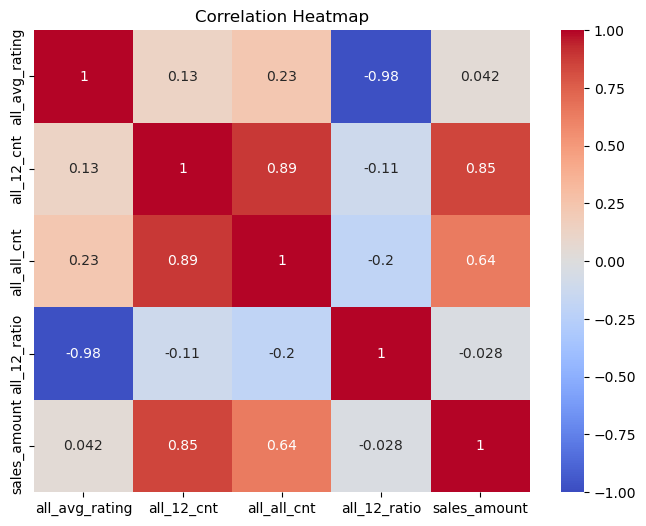

In [28]:

# 히트맵 생성
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

## 회귀 분석 

In [30]:
selected_columns = ["sales_amount","all_avg_rating","all_all_cnt","all_12_cnt","all_12_ratio"]
data1 = data[selected_columns].dropna()

In [32]:
Y = data1['sales_amount']
X = data1.drop(columns=["sales_amount"])

In [34]:
X

,all_avg_rating,all_all_cnt,all_12_cnt,all_12_ratio
0,4.512716,983.0,73.0,0.074262
1,3.854545,440.0,103.0,0.234091
2,4.163462,416.0,61.0,0.146635
4,4.833333,6.0,0.0,0.000000
5,3.800512,391.0,100.0,0.255754
...,...,...,...,...
383,4.591304,920.0,52.0,0.056522
385,3.853425,730.0,166.0,0.227397
386,4.371156,943.0,100.0,0.106045
388,4.150602,332.0,48.0,0.144578


In [36]:
X = sm.add_constant(X)

In [38]:
model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           sales_amount   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     301.6
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          3.16e-111
Time:                        16:41:55   Log-Likelihood:                -5717.3
No. Observations:                 350   AIC:                         1.144e+04
Df Residuals:                     345   BIC:                         1.146e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -8.573e+06   1.03e+07     -0.

In [40]:
# 다중 공선성
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

         Variable          VIF
0           const  4050.532772
1  all_avg_rating    25.671249
2     all_all_cnt     5.110154
3      all_12_cnt     4.897124
4    all_12_ratio    25.268902


## 평점과 판매액 간의 시계열 

In [42]:
monthly_sales_by_category = data.groupby(['yr_month', 'category_type']).agg({'sales_amount': 'sum', 'all_avg_rating':'mean'}).reset_index()

In [44]:
mattress_data = monthly_sales_by_category[monthly_sales_by_category["category_type"] == "Mattress"]
non_mattress_data = monthly_sales_by_category[monthly_sales_by_category["category_type"] == "Non-Mattress"]

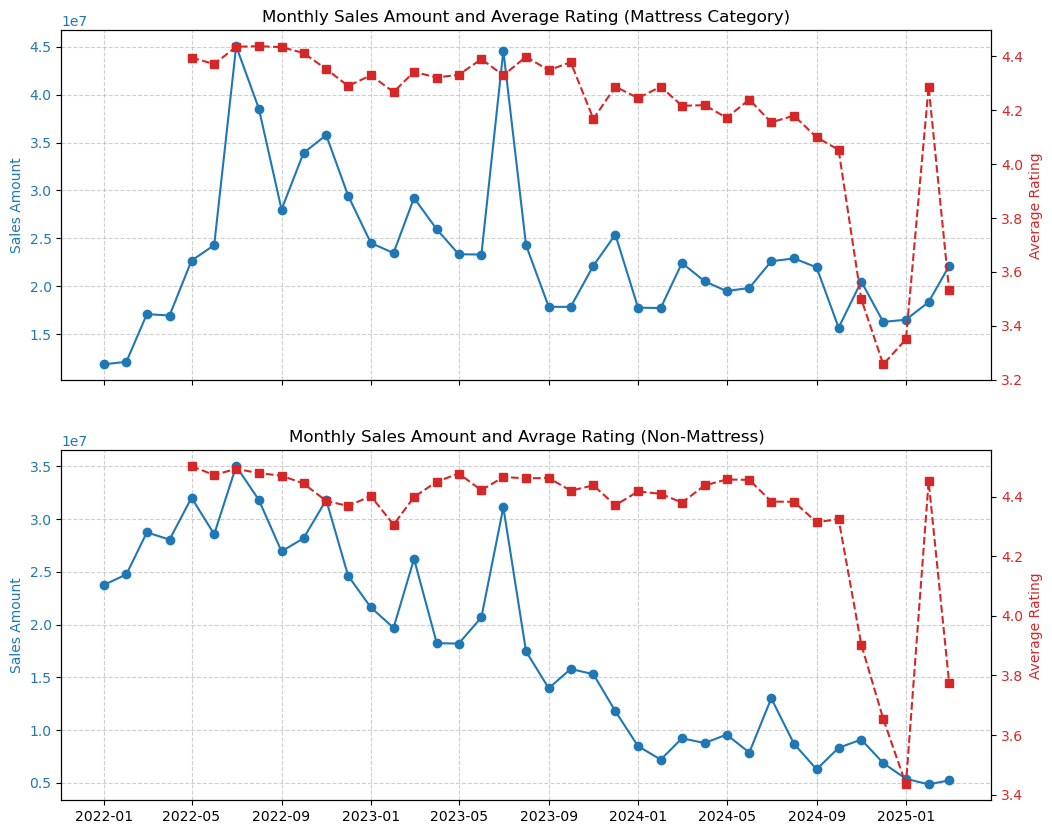

In [46]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,10), sharex=True)

ax1.set_title("Monthly Sales Amount and Average Rating (Mattress Category)") 
#ax1.set_xlabel("Month")
ax1.set_ylabel("Sales Amount", color='tab:blue')
ax1.plot(mattress_data['yr_month'], mattress_data['sales_amount'], marker='o', color='tab:blue', label="Sales Amount")
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.6)

ax3 = ax1.twinx()
ax3.set_ylabel("Average Rating", color='tab:red')
ax3.plot(mattress_data['yr_month'], mattress_data['all_avg_rating'], marker='s', color='tab:red', linestyle='dashed', label="Average Rating")
ax3.tick_params(axis='y', labelcolor='tab:red')

ax2.set_title("Monthly Sales Amount and Avrage Rating (Non-Mattress)")
ax2.set_ylabel("Sales Amount", color='tab:blue')
ax2.plot(non_mattress_data['yr_month'], non_mattress_data['sales_amount'], marker='o', color='tab:blue', label="Sales Amount")
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.grid(True, linestyle='--', alpha=0.6)

ax4 = ax2.twinx()
ax4.set_ylabel("Average Rating", color='tab:red')
ax4.plot(non_mattress_data['yr_month'], non_mattress_data['all_avg_rating'], marker='s', color='tab:red', linestyle='dashed', label="Average Rating")
ax4.tick_params(axis='y', labelcolor='tab:red')

plt.show()


In [48]:
#non_mattress_data['written_avg_rating'].max()
non_mattress_data['all_avg_rating'].min()

3.434789467375

## 평점 수준별 매출 히스토그램

In [51]:
bins = [i/10 for i in range(int(data['all_avg_rating'].min()*10), int(data['all_avg_rating'].max() * 10) + 2)]

In [53]:
data['rating_bin'] = pd.cut(data['all_avg_rating'], bins=bins, right=False)

In [55]:
data[data['category_type']=="Mattress"]['sales_amount'].sum()

912267872.8899999

In [57]:
rating_sales = data.groupby(["rating_bin", "category_type"])["sales_amount"].sum().unstack().fillna(0) / 1000000

C:\Users\최태욱\AppData\Local\Temp\ipykernel_408\1249324559.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales = data.groupby(["rating_bin", "category_type"])["sales_amount"].sum().unstack().fillna(0) / 1000000


In [59]:
rating_sales_by_category = data.groupby(['rating_bin','financial_category'])['sales_amount'].sum().unstack().fillna(0)/1000000

C:\Users\최태욱\AppData\Local\Temp\ipykernel_408\3906643850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_by_category = data.groupby(['rating_bin','financial_category'])['sales_amount'].sum().unstack().fillna(0)/1000000


In [61]:
rating_sales_by_category

financial_category,Box Springs,Foam Mattresses,Non Bedroom Furniture,Other Frames & Beds,Others,Platform Beds,SmartBases,Sofa,Spring Mattresses,Toppers
rating_bin,,,,,,,,,,
"[1.0, 1.1)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.089498,0.000000,0.000000
"[1.1, 1.2)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.2, 1.3)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.3, 1.4)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.4, 1.5)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.5, 1.6)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.6, 1.7)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.7, 1.8)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.8, 1.9)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


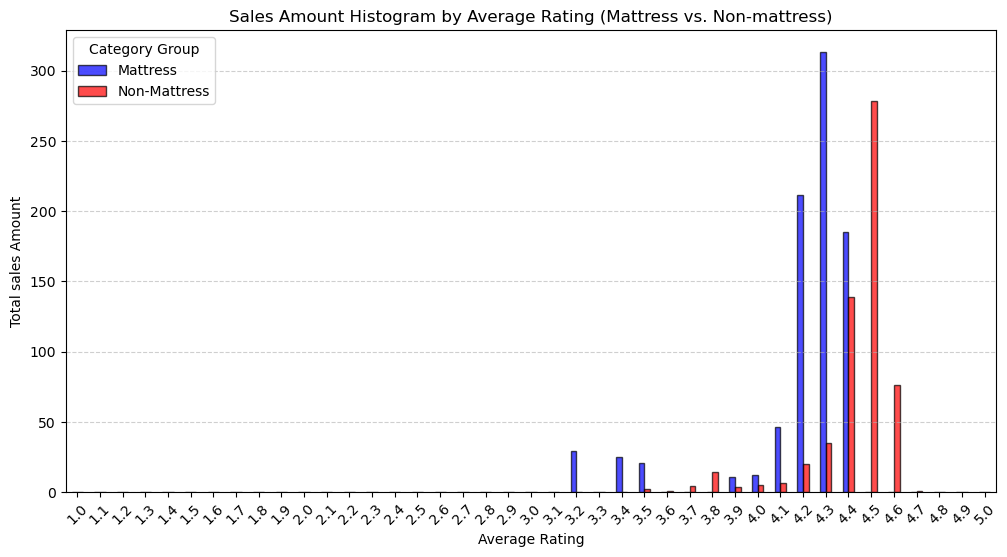

In [63]:
fig, ax = plt.subplots(figsize=(12,6))
rating_sales.plot(kind='bar', stacked=False, color=['blue','red'], edgecolor='black', alpha=0.7, ax=ax)

x_labels = [round(b.left, 1) for b in rating_sales.index]
ax.set_xticklabels(x_labels, rotation=45)

plt.xlabel("Average Rating")
plt.ylabel("Total sales Amount")
plt.title("Sales Amount Histogram by Average Rating (Mattress vs. Non-mattress)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Category Group", labels=["Mattress", "Non-Mattress"])

plt.show()





## Category별 히스토그램 

In [65]:
data

,yr_month,financial_category,written_avg_rating,written_12_cnt,written_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,category_type,rating_bin
0,2022-12-01,SmartBases,4.038674,37,181,0.204420,4.512716,73.0,983.0,0.074262,1729285.82,17377,Non-Mattress,"[4.5, 4.6)"
1,2024-12-01,Platform Beds,3.854545,103,440,0.234091,3.854545,103.0,440.0,0.234091,4021850.94,40099,Non-Mattress,"[3.8, 3.9)"
2,2023-09-01,Toppers,3.106061,31,66,0.469697,4.163462,61.0,416.0,0.146635,240646.93,4615,Non-Mattress,"[4.1, 4.2)"
3,2022-01-01,Non Bedroom Furniture,3.853333,19,75,0.253333,NaN,NaN,NaN,NaN,518281.03,4766,Non-Mattress,NaN
4,2024-11-01,Others,5.000000,0,2,0.000000,4.833333,0.0,6.0,0.000000,41752.46,1279,Non-Mattress,"[4.8, 4.9)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,2023-03-01,Toppers,2.700637,89,157,0.566879,3.853425,166.0,730.0,0.227397,1018152.28,20058,Non-Mattress,"[3.8, 3.9)"
386,2023-11-01,Box Springs,3.840206,49,194,0.252577,4.371156,100.0,943.0,0.106045,4148741.49,31839,Non-Mattress,"[4.3, 4.4)"
387,2022-02-01,Box Springs,4.133739,56,329,0.170213,NaN,NaN,NaN,NaN,6632445.72,48676,Non-Mattress,NaN
388,2024-01-01,Toppers,3.041667,21,48,0.437500,4.150602,48.0,332.0,0.144578,185152.78,3537,Non-Mattress,"[4.1, 4.2)"


In [67]:
categories = data['financial_category'].unique()
num_categories = len(categories)

In [69]:
bins1 = [round(x * 0.1, 1) for x in range(int(data['all_avg_rating'].min()*10)-1, int(data['all_avg_rating'].max()*10)+2)]
#subset['rating_bin']=data.cut(subset['written_avg_rating'], bins=bins1)

C:\Users\최태욱\AppData\Local\Temp\ipykernel_408\106508149.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000
C:\Users\최태욱\AppData\Local\Temp\ipykernel_408\106508149.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000
C:\Users\최태욱\AppData\Local\Temp\ipykernel_408\106508149.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current 

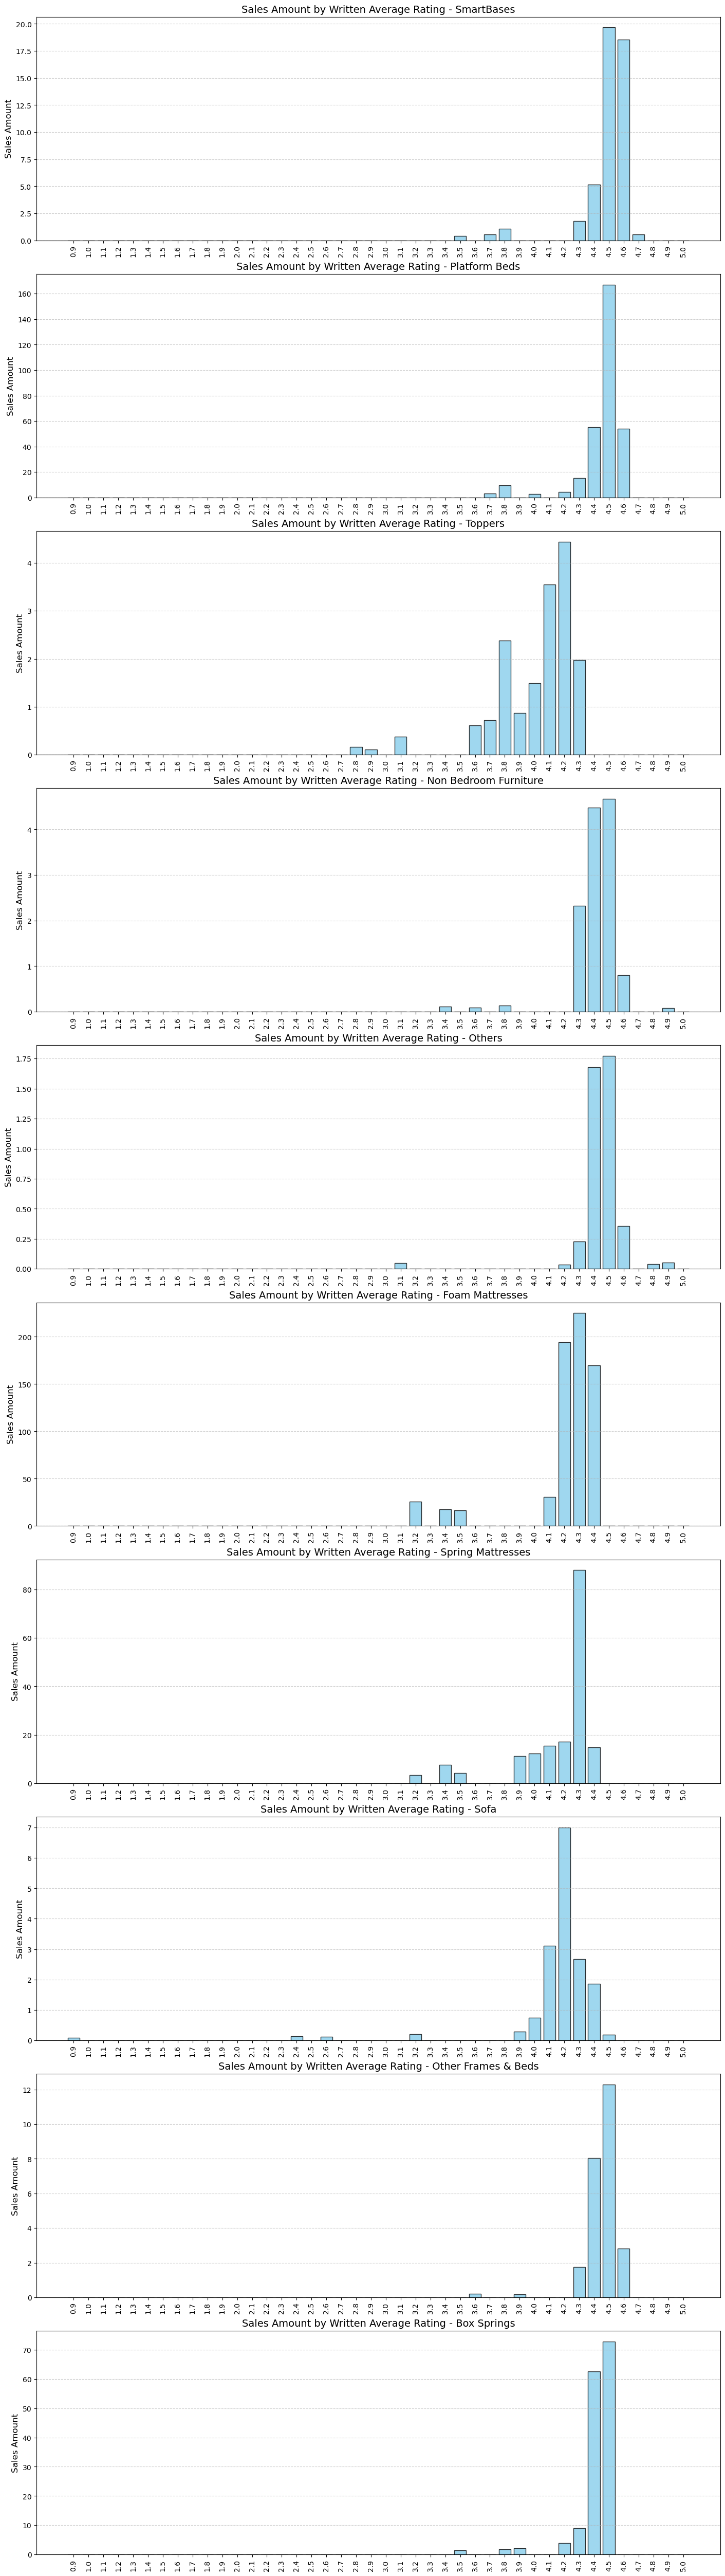

In [71]:
fig, axes = plt.subplots(num_categories, 1, figsize=(14,5*num_categories), constrained_layout=True)

for i, category in enumerate(categories):
    subset = data[data['financial_category']==category].copy()
    subset['rating_bin1'] = pd.cut(subset['all_avg_rating'], bins=bins1)
    rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000

    x_labels = [round(interval.left,1) for interval in rating_sales_sum.index]
    
    axes[i].bar(range(len(x_labels)), rating_sales_sum.values, color='skyblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Sales Amount by Written Average Rating - {category}', fontsize=14)
    #axes[i].set_xlabel('Written Average Rating (0.1 intervals)', fontsize=12)
    axes[i].set_ylabel('Sales Amount', fontsize=12)
    axes[i].set_xticks(range(len(x_labels)))
    axes[i].set_xticklabels(x_labels, rotation=90)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.show()